# Type C — Funded-Continuation Surplus Hedge

**Hedge Type:** Hedge through the challenge, get funded, keep hedging, and deliberately **oversize** the funded hedge so that a failure event produces **surplus profit**, not just cost recovery.

**Method split (same as Types A & B):**
- **Static DD → Cross-firm pair:** Surplus doesn't apply — the cross-firm pair already
  extracts floor(DD% / target%) payouts naturally. There's no single "failure event"
  that triggers surplus; the pair just runs out of drawdown room. **Type C = Type B for static DD.**
- **Trailing DD → Personal hedge through funded:** Surplus is meaningful here. Oversize the
  personal hedge: $S = (L + P) / DD$. When funded fails, the hedge pays out L + P (stack + surplus).

## EV Formula (Trailing DD only)

$$\text{EV}_C = \text{funded withdrawals} + \text{expected surplus from failure} - \text{total hedge drag}$$

## Hedge Sizing

**Type B (recovery only):** $S = \dfrac{L}{DD}$

**Type C (recovery + surplus):** $S = \dfrac{L + P}{DD}$

## Important

- **Cross-firm pairing (static DD):** Both funded accounts MUST be at **different prop firms**.
  Same-firm pairing gets both accounts closed.
- **Personal hedge (trailing DD):** Your own brokerage account hedges against the funded account.

---

**Reference:** [hedging-explained.md](../Product/hedging-explained.md) §5 Type C

## 0 — Setup & Imports

In [1]:
import sys, os, json, math, glob, importlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

WS_ROOT = os.environ.get(
    "WORKSPACE_ROOT",
    r"C:\Users\sossi\Desktop\Business\Orchestrator Hedge Edge"
)
if WS_ROOT not in sys.path:
    sys.path.insert(0, WS_ROOT)

STRATEGY_ROOT = os.path.join(WS_ROOT, "Business", "STRATEGY")
DATA_DIR = os.path.join(STRATEGY_ROOT, "resources", "PropFirmData")

exec_path = os.path.join(STRATEGY_ROOT, "executions")
if exec_path not in sys.path:
    sys.path.insert(0, exec_path)

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 120

# ── Tuneable assumptions ──
FUNDED_TARGET = 0.08     # 8% funded target (challenge phase)
SPREAD_COST   = 0.0003   # 3 pips per side
RESIZES_PER_PHASE = 20

# ── Type C funded-phase assumptions ──
FUNDED_WITHDRAWAL_PCT = 0.04   # 4% withdrawal per cycle
FUNDED_CYCLES = 6              # cycles modelled
FUNDED_SURVIVAL_RATE = 0.80    # survival prob per cycle
FUNDED_HEDGE_DRAG_PCT = 0.015  # hedge drag per cycle (% of account)
SURPLUS_TARGET_PCT = 0.02      # desired surplus = 2% of account size on failure

print("Type C notebook ready.")
print(f"Challenge: funded_target={FUNDED_TARGET*100:.0f}%, spread={SPREAD_COST}")
print(f"Funded: withdrawal={FUNDED_WITHDRAWAL_PCT*100:.1f}%/cycle, "
      f"survival={FUNDED_SURVIVAL_RATE*100:.0f}%/cycle, "
      f"drag={FUNDED_HEDGE_DRAG_PCT*100:.1f}%/cycle")
print(f"Surplus target: {SURPLUS_TARGET_PCT*100:.1f}% of account on failure")

Type C notebook ready.
Challenge: funded_target=8%, spread=0.0003
Funded: withdrawal=4.0%/cycle, survival=80%/cycle, drag=1.5%/cycle
Surplus target: 2.0% of account on failure


## 1 — Load Data

In [2]:
import sqlite3

DB_PATH = os.path.join(DATA_DIR, "propmatch_model_input.db")
conn = sqlite3.connect(DB_PATH)
conn.row_factory = sqlite3.Row
rows = conn.execute("""
    SELECT * FROM v_fx_model
    WHERE survival_model_class IN ('challenge_static', 'challenge_trailing')
    ORDER BY account_size, fee_assumed
""").fetchall()
conn.close()

challenges = []
for row in rows:
    d = dict(row)
    pt = d.pop("profit_targets_json", None)
    if isinstance(pt, str):
        import json as _json
        try:
            d["profit_targets"] = _json.loads(pt)
        except (ValueError, TypeError):
            d["profit_targets"] = []
    else:
        d["profit_targets"] = pt or []
    # Set drawdown_type from survival_model_class for downstream classify_drawdown()
    if d.get("survival_model_class") == "challenge_trailing":
        d["drawdown_type"] = "trailing"
    elif (d.get("max_loss_type") or "").lower() == "trailing":
        d["drawdown_type"] = "trailing"
    else:
        d["drawdown_type"] = d.get("drawdown_type") or "static"
    challenges.append(d)

print(f"Loaded {len(challenges)} FX challenges from DB")

def classify_drawdown(dd_type_str):
    """Only explicit 'trailing' keyword -> trailing. Everything else -> static."""
    if not dd_type_str or dd_type_str == "-":
        return "static"
    if "trailing" in dd_type_str.lower():
        return "trailing"
    return "static"

df_raw = pd.DataFrame(challenges)
df_raw["dd_category"] = df_raw["drawdown_type"].fillna("-").apply(classify_drawdown)

print(f"\nDrawdown breakdown:")
for cat, cnt in df_raw["dd_category"].value_counts().items():
    print(f"  {cat}: {cnt} challenges")


Loaded 368 FX challenges from DB

Drawdown breakdown:
  static: 348 challenges
  trailing: 20 challenges


## 2 — Type C Model: Recovery + Surplus (Method-Aware)

### Static DD — Cross-Firm Pair (Type C = Type B)

For static DD with cross-firm pairing, surplus doesn't apply:
- The pair already extracts max payouts before the losing side hits its drawdown limit
- There's no single "failure event" — the pair exhausts naturally
- **For static DD challenges, Type C produces the same results as Type B**

### Trailing DD — Personal Hedge with Surplus

Type B sizes the funded hedge for **recovery only** ($S = L / DD$).
Type C sizes for **recovery + surplus** ($S = (L + P) / DD$).

The oversized hedge means:
- More drag per cycle (bigger hedge = more cost when funded account profits)
- But failure produces **L + P**, not just **L** — that extra P is pure surplus profit

### The tradeoff

| | Type B | Type C |
|---|---|---|
| Hedge sizing | $L / DD$ | $(L + P) / DD$ |
| Drag per cycle | Lower | Higher |
| Failure outcome | Recovers stack only | Recovers stack + surplus |
| Static DD behaviour | Cross-firm pair payouts | Same (no change from B) |
| Capital required | Lower | Higher |

In [ ]:
from notebook_review_adjustment import build_review_adjusted_dataframe

def compute_type_a_cost(challenge, funded_target_pct=FUNDED_TARGET,
                        spread_cost_pct=SPREAD_COST,
                        resizes_per_phase=RESIZES_PER_PHASE):
    """Challenge-phase cost stack (Type A baseline)."""
    S = challenge.get("account_size", 0)
    fee = challenge.get("fee_assumed") or challenge.get("fee_original") or challenge.get("fee_discounted") or 0
    targets = challenge.get("profit_targets") or []
    steps = challenge.get("steps") or len(targets) or 2
    dd_max_pct = (challenge.get("max_drawdown_pct") or 10.0) / 100.0
    split = (challenge.get("profit_split_pct") or 80.0) / 100.0
    dd_category = classify_drawdown(challenge.get("drawdown_type", ""))

    if targets:
        phase_targets = [t / 100.0 for t in targets]
    else:
        phase_targets = [0.08 / steps] * steps

    L = fee
    for phase_idx in range(steps):
        pt = phase_targets[phase_idx] if phase_idx < len(phase_targets) else phase_targets[-1]
        if dd_category == "trailing":
            N = resizes_per_phase
            dm = pt / N
            for _ in range(N):
                hs = L / dd_max_pct
                L += hs * dm + hs * spread_cost_pct * 2
        else:
            hs = L / dd_max_pct if dd_max_pct > 0 else 0
            L += hs * pt + hs * spread_cost_pct * 2

    return {
        "firm": challenge.get("firm"),
        "account_size": S,
        "fee": round(fee, 2),
        "steps": steps,
        "dd_category": dd_category,
        "dd_max_pct": dd_max_pct,
        "split": split,
        "challenge_cost": round(L, 2),
    }


def compute_type_bc(challenge,
                    funded_target_pct=FUNDED_TARGET,
                    spread_cost_pct=SPREAD_COST,
                    resizes_per_phase=RESIZES_PER_PHASE,
                    withdrawal_pct=FUNDED_WITHDRAWAL_PCT,
                    n_cycles=FUNDED_CYCLES,
                    survival_rate=FUNDED_SURVIVAL_RATE,
                    hedge_drag_pct=FUNDED_HEDGE_DRAG_PCT,
                    surplus_target_pct=0.0):
    """
    Unified Type B/C model (method-aware).

    Static DD  -> Cross-firm pair: Type C = Type B (surplus doesn't apply).
                  Cost = 2 x challenge, payouts = floor(DD/target) per pair.
    Trailing DD -> Personal hedge: surplus_target_pct > 0 oversizes the hedge.
                   Failure pays L + P. Drag scales with (L+P)/DD.
    """
    base = compute_type_a_cost(challenge, funded_target_pct, spread_cost_pct, resizes_per_phase)
    S = base["account_size"]
    split = base["split"]
    dd = base["dd_max_pct"]
    dd_category = base["dd_category"]
    single_cost = base["challenge_cost"]

    if dd_category == "static":
        total_cost = 2 * single_cost
        payout_cycles = max(1, int(dd / funded_target_pct)) if funded_target_pct > 0 else 1
        funded_payout = S * funded_target_pct * split * payout_cycles

        ev = funded_payout - total_cost
        P = S * surplus_target_pct

        challenge_hs = single_cost / dd if dd > 0 else 0
        challenge_capital = challenge_hs / 100 + challenge_hs * dd * 1.5

        return {
            "firm": base["firm"],
            "account_size": S,
            "fee": base["fee"],
            "steps": base["steps"],
            "dd_category": dd_category,
            "method": "cross-firm-pair",
            "challenge_cost": round(total_cost, 2),
            "surplus_target": round(P, 2),
            "type_a_ev": round(ev, 2),
            "total_withdrawals": round(funded_payout, 2),
            "total_drag": 0.0,
            "expected_surplus": 0.0,
            "ev": round(ev, 2),
            "ev_vs_type_a": 0.0,
            "capital_required": round(challenge_capital, 2),
            "capital_efficiency": round(ev / challenge_capital, 4) if challenge_capital > 0 else 0,
            "cycles": [],
        }

    method = "personal-hedge"
    L = single_cost
    P = S * surplus_target_pct

    N_funded = resizes_per_phase
    dm_funded = funded_target_pct / N_funded
    for _ in range(N_funded):
        hs = L / dd
        L += hs * dm_funded + hs * spread_cost_pct * 2

    type_a_total_cost = L
    type_a_payout = S * funded_target_pct * split
    type_a_ev = type_a_payout - type_a_total_cost

    total_withdrawals = 0.0
    total_drag = 0.0
    expected_surplus = 0.0
    cycle_details = []
    cum_survival = 1.0

    for k in range(1, n_cycles + 1):
        prob_alive = cum_survival

        withdrawal = S * withdrawal_pct * split
        exp_withdrawal = withdrawal * prob_alive

        base_drag = S * hedge_drag_pct
        drag_multiplier = (L + P) / L if L > 0 else 1.0
        drag = base_drag * drag_multiplier
        exp_drag = drag * prob_alive

        L_cycle_start = L
        L += drag

        prob_fail = prob_alive * (1 - survival_rate)
        surplus_on_fail = P
        exp_surplus = surplus_on_fail * prob_fail

        hedge_size = (L + P) / dd if dd > 0 else 0
        margin = hedge_size / 100
        buffer = hedge_size * dd * 1.5
        capital = margin + buffer

        total_withdrawals += exp_withdrawal
        total_drag += exp_drag
        expected_surplus += exp_surplus

        cycle_details.append({
            "cycle": k,
            "prob_alive": round(prob_alive, 4),
            "insured_stack": round(L_cycle_start, 2),
            "surplus_target": round(P, 2),
            "hedge_total_cover": round(L_cycle_start + P, 2),
            "hedge_size": round((L_cycle_start + P) / dd if dd > 0 else 0, 2),
            "withdrawal": round(withdrawal, 2),
            "exp_withdrawal": round(exp_withdrawal, 2),
            "drag": round(drag, 2),
            "exp_drag": round(exp_drag, 2),
            "prob_fail": round(prob_fail, 4),
            "exp_surplus": round(exp_surplus, 2),
            "capital": round(capital, 2),
        })

        cum_survival *= survival_rate

    ev = total_withdrawals + expected_surplus - total_drag
    max_capital = max(c["capital"] for c in cycle_details) if cycle_details else 0

    return {
        "firm": base["firm"],
        "account_size": S,
        "fee": base["fee"],
        "steps": base["steps"],
        "dd_category": dd_category,
        "method": method,
        "challenge_cost": base["challenge_cost"],
        "surplus_target": round(P, 2),
        "type_a_ev": round(type_a_ev, 2),
        "total_withdrawals": round(total_withdrawals, 2),
        "total_drag": round(total_drag, 2),
        "expected_surplus": round(expected_surplus, 2),
        "ev": round(ev, 2),
        "ev_vs_type_a": round(ev - type_a_ev, 2),
        "capital_required": round(max_capital, 2),
        "capital_efficiency": round(ev / max_capital, 4) if max_capital > 0 else 0,
        "cycles": cycle_details,
    }


# Compute all three types for comparison
results_b = [compute_type_bc(c, surplus_target_pct=0) for c in challenges]
results_c = [compute_type_bc(c, surplus_target_pct=SURPLUS_TARGET_PCT) for c in challenges]

df_b = build_review_adjusted_dataframe(
    results_b,
    challenges,
    raw_ev_col="ev",
    revenue_cols=["total_withdrawals"],
    capital_col="capital_required",
    fee_col="fee",
)
df_c = build_review_adjusted_dataframe(
    results_c,
    challenges,
    raw_ev_col="ev",
    revenue_cols=["total_withdrawals"],
    capital_col="capital_required",
    fee_col="fee",
)

print(f"Type B - Positive EV (review-adj): {(df_b['EV_review_adj'] > 0).sum()}/{len(df_b)}, Avg: ${df_b['EV_review_adj'].mean():,.2f}")
print(f"Type C - Positive EV (review-adj): {(df_c['EV_review_adj'] > 0).sum()}/{len(df_c)}, Avg: ${df_c['EV_review_adj'].mean():,.2f}")
print(f"Surplus target: ${(df_c['surplus_target'].iloc[0]):,.0f} to ${df_c['surplus_target'].max():,.0f}")
print(f"Average Type C advantage over B (review-adj): ${(df_c['EV_review_adj'] - df_b['EV_review_adj']).mean():,.2f}")

print(f"\\n-- By Method --")
for m in ["cross-firm-pair", "personal-hedge"]:
    mask_c = df_c["method"] == m if "method" in df_c.columns else pd.Series([False]*len(df_c))
    if mask_c.any():
        mask_b = df_b["method"] == m if "method" in df_b.columns else mask_c
        print(
            f"  {m:18s}: B avg=${df_b.loc[mask_b, 'EV_review_adj'].mean():,.2f}, "
            f"C avg=${df_c.loc[mask_c, 'EV_review_adj'].mean():,.2f}"
        )

Type B - Positive EV: 301/368, Avg: $1,715.99
Type C - Positive EV: 301/368, Avg: $1,731.74
Surplus target: $40 to $10,000
Average Type C advantage over B: $15.75
\n-- By Method --
  cross-firm-pair   : B avg=$1,488.25, C avg=$1,488.25
  personal-hedge    : B avg=$5,678.72, C avg=$5,968.47


## 3 — Type C Rankings

In [ ]:
rank_cols = [
    "firm", "account_size", "dd_category", "review_rating", "review_count", "review_factor", "fee",
    "challenge_cost", "surplus_target",
    "total_withdrawals", "total_drag", "expected_surplus",
    "ev", "EV_review_adj", "ev_vs_type_a",
    "capital_required", "capital_efficiency_review_adj"
 ]

df_c.sort_values("EV_review_adj", ascending=False)[rank_cols].head(30).style.format({
    "review_rating": "{:.1f}",
    "review_count": "{:,.0f}",
    "review_factor": "{:.3f}",
    "fee": "${:,.0f}",
    "challenge_cost": "${:,.2f}",
    "surplus_target": "${:,.0f}",
    "total_withdrawals": "${:,.2f}",
    "total_drag": "${:,.2f}",
    "expected_surplus": "${:,.2f}",
    "ev": "${:,.2f}",
    "EV_review_adj": "${:,.2f}",
    "ev_vs_type_a": "${:+,.2f}",
    "capital_required": "${:,.0f}",
    "capital_efficiency_review_adj": "{:.4f}",
    "account_size": "${:,}",
}).bar(subset=["EV_review_adj"], color="#5fba7d").bar(
    subset=["expected_surplus"], color="#ff9800"
).set_caption(
    f"Type C Rankings — Top 30 by Review-Adjusted EV (surplus={SURPLUS_TARGET_PCT*100:.1f}% of account)"
 )

,firm,account_size,dd_category,fee,challenge_cost,surplus_target,total_withdrawals,total_drag,expected_surplus,ev,ev_vs_type_a,capital_required,capital_efficiency
365,FXIFY,"$400,000",trailing,"$2,950","$16,153.76","$8,000","$47,222.78","$25,638.69","$5,902.85","$27,486.94","$+41,597.62","$142,363",0.1931
332,AquaFunded,"$200,000",trailing,$897,"$4,911.84","$4,000","$26,562.82","$13,620.93","$2,951.42","$15,893.31","$+13,568.05","$60,438",0.2630
333,Blue Guardian,"$200,000",trailing,$921,"$4,575.99","$4,000","$25,087.10","$13,753.37","$2,951.42","$14,285.15","$+11,934.28","$59,387",0.2405
340,FXIFY,"$200,000",trailing,"$1,049","$5,744.17","$4,000","$23,611.39","$13,344.64","$2,951.42","$13,218.18","$+14,539.03","$63,139",0.2094
361,FundedElite,"$300,000",static,$899,"$6,626.30","$6,000","$19,200.00",$0.00,$0.00,"$12,573.70",$+0.00,"$5,384",2.3354
364,Fintokei,"$400,000",static,"$2,399","$13,916.30","$8,000","$25,600.00",$0.00,$0.00,"$11,683.70",$+0.00,"$11,133",1.0495
367,Nordic Funder,"$500,000",static,"$2,760","$20,343.24","$10,000","$32,000.00",$0.00,$0.00,"$11,656.76",$+0.00,"$16,529",0.7052
320,Goat Funded Trader,"$150,000",trailing,$728,"$3,630.45","$3,000","$17,708.54","$10,235.90","$2,213.57","$9,686.21","$+9,010.92","$45,160",0.2145
357,Audacity Capital,"$240,000",static,"$1,090","$4,870.64","$4,800","$14,400.00",$0.00,$0.00,"$9,529.36",$+0.00,"$3,815",2.4976
362,FundedElite,"$300,000",static,"$1,499","$9,825.18","$6,000","$19,200.00",$0.00,$0.00,"$9,374.82",$+0.00,"$7,983",1.1744


## 4 — Three-Way Comparison: Type A vs B vs C

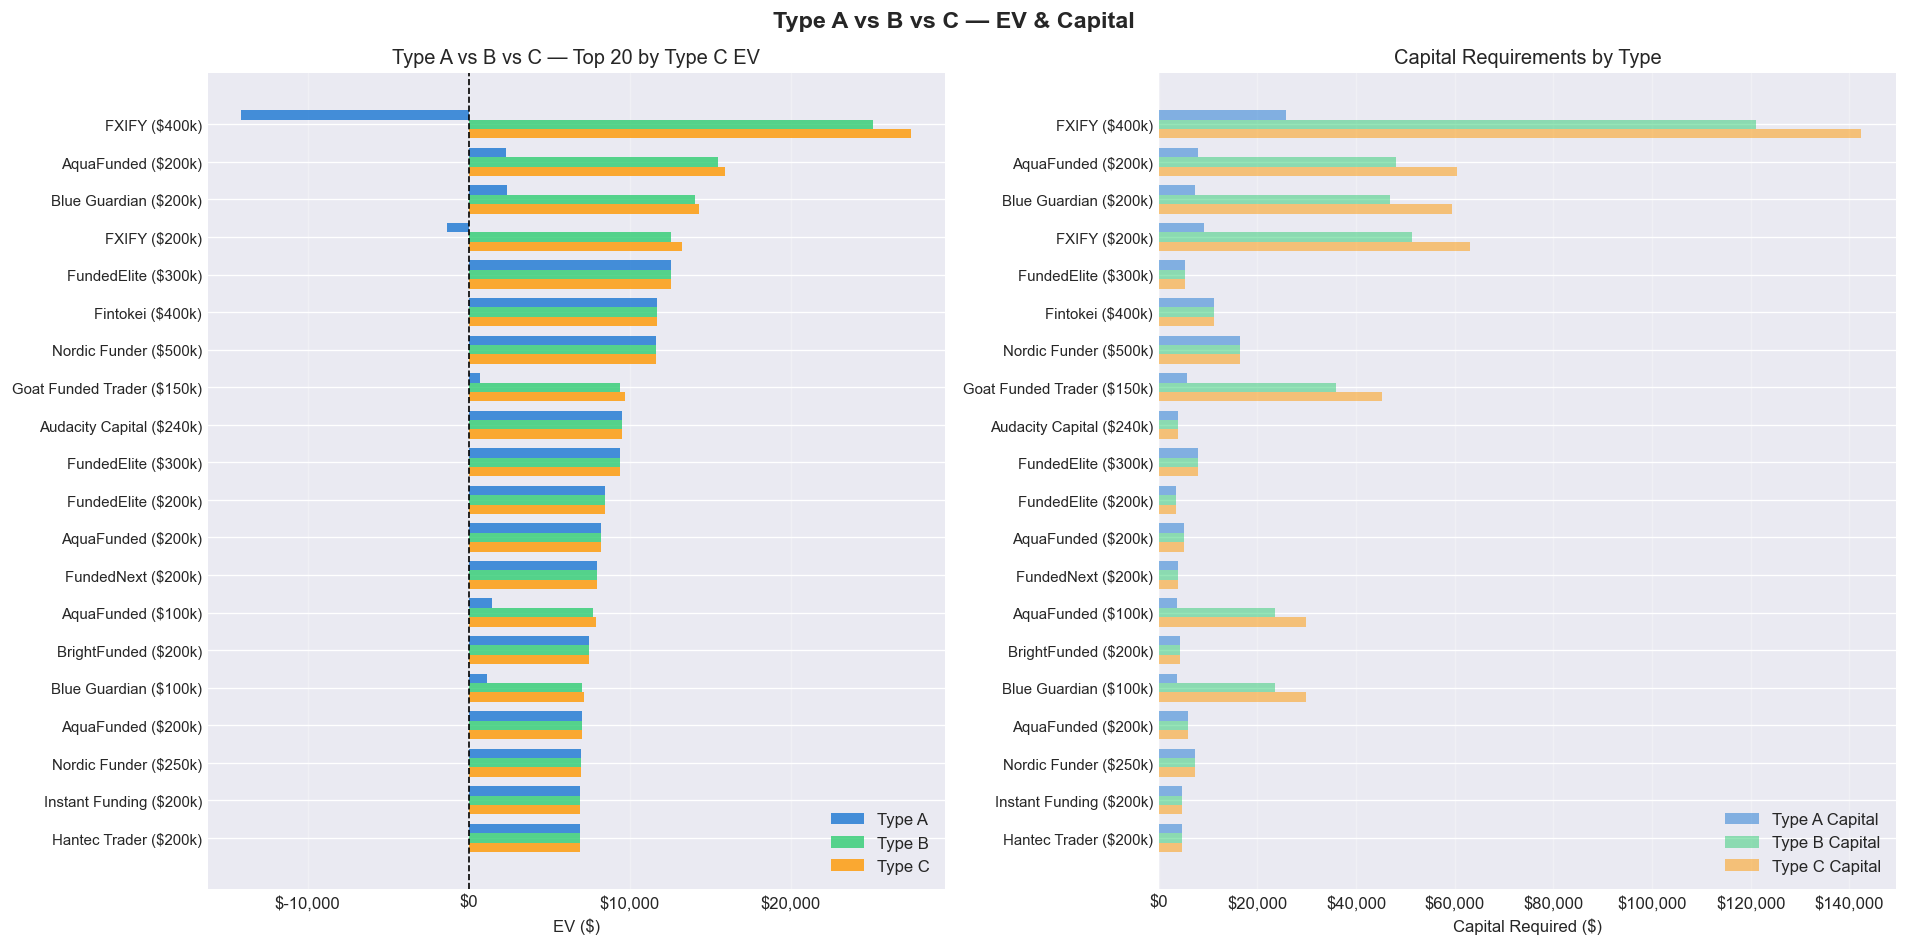

In [5]:
# Build comparison DataFrame
df_comp = pd.DataFrame({
    "firm": df_c["firm"],
    "account_size": df_c["account_size"],
    "dd_category": df_c["dd_category"],
    "type_a_ev": df_c["type_a_ev"],
    "type_b_ev": df_b["ev"],
    "type_c_ev": df_c["ev"],
    "surplus_value": df_c["expected_surplus"],
    "extra_drag_c_vs_b": df_c["total_drag"] - df_b["total_drag"],
    "cap_a": [r["challenge_cost"] / r["dd_max_pct"] / 100 +
              r["challenge_cost"] / r["dd_max_pct"] * r["dd_max_pct"] * 1.5
              for r in [compute_type_a_cost(c) for c in challenges]],
    "cap_b": df_b["capital_required"],
    "cap_c": df_c["capital_required"],
})

# Top 20 by Type C EV
top20 = df_comp.nlargest(20, "type_c_ev").sort_values("type_c_ev", ascending=True).copy()
top20["label"] = top20.apply(
    lambda r: f"{r['firm']} (${r['account_size']/1000:.0f}k)", axis=1
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Left: EV comparison
y = np.arange(len(top20))
h = 0.25

ax1.barh(y + h, top20["type_a_ev"], h, label="Type A", color="#1976d2", alpha=0.8)
ax1.barh(y, top20["type_b_ev"], h, label="Type B", color="#2ecc71", alpha=0.8)
ax1.barh(y - h, top20["type_c_ev"], h, label="Type C", color="#ff9800", alpha=0.8)

ax1.set_yticks(y)
ax1.set_yticklabels(top20["label"], fontsize=9)
ax1.axvline(x=0, color="black", linewidth=1, linestyle="--")
ax1.set_xlabel("EV ($)")
ax1.set_title("Type A vs B vs C — Top 20 by Type C EV")
ax1.legend(loc="lower right")
ax1.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax1.grid(axis='x', alpha=0.3)

# Right: capital comparison
ax2.barh(y + h, top20["cap_a"], h, label="Type A Capital", color="#1976d2", alpha=0.5)
ax2.barh(y, top20["cap_b"], h, label="Type B Capital", color="#2ecc71", alpha=0.5)
ax2.barh(y - h, top20["cap_c"], h, label="Type C Capital", color="#ff9800", alpha=0.5)

ax2.set_yticks(y)
ax2.set_yticklabels(top20["label"], fontsize=9)
ax2.set_xlabel("Capital Required ($)")
ax2.set_title("Capital Requirements by Type")
ax2.legend(loc="lower right")
ax2.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax2.grid(axis='x', alpha=0.3)

plt.suptitle("Type A vs B vs C — EV & Capital", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 5 — Funded Phase Walkthrough (Single Challenge)

In [6]:
best_idx = df_c["ev"].idxmax()
best_c = results_c[best_idx]
best_b = results_b[best_idx]

print(f"Challenge: {best_c['firm']} — ${best_c['account_size']:,}")
print(f"Challenge cost: ${best_c['challenge_cost']:,.2f}")
print(f"Surplus target: ${best_c['surplus_target']:,.2f}")
print(f"")
print(f"  Type A EV:  ${best_c['type_a_ev']:,.2f}")
print(f"  Type B EV:  ${best_b['ev']:,.2f}")
print(f"  Type C EV:  ${best_c['ev']:,.2f}")
print(f"  C vs A:     ${best_c['ev_vs_type_a']:+,.2f}")
print(f"  C vs B:     ${best_c['ev'] - best_b['ev']:+,.2f}")
print()

df_cyc = pd.DataFrame(best_c["cycles"])
df_cyc.style.format({
    "prob_alive": "{:.1%}",
    "insured_stack": "${:,.2f}",
    "surplus_target": "${:,.0f}",
    "hedge_total_cover": "${:,.2f}",
    "hedge_size": "${:,.0f}",
    "withdrawal": "${:,.2f}",
    "exp_withdrawal": "${:,.2f}",
    "drag": "${:,.2f}",
    "exp_drag": "${:,.2f}",
    "prob_fail": "{:.1%}",
    "exp_surplus": "${:,.2f}",
    "capital": "${:,.0f}",
}).set_caption(f"Type C Cycle Detail — {best_c['firm']} ${best_c['account_size']:,}")

Challenge: FXIFY — $400,000
Challenge cost: $16,153.76
Surplus target: $8,000.00

  Type A EV:  $-14,110.68
  Type B EV:  $25,087.10
  Type C EV:  $27,486.94
  C vs A:     $+41,597.62
  C vs B:     $+2,399.84



,cycle,prob_alive,insured_stack,surplus_target,hedge_total_cover,hedge_size,withdrawal,exp_withdrawal,drag,exp_drag,prob_fail,exp_surplus,capital
0,1,100.0%,"$39,710.68","$8,000","$47,710.68","$477,107","$12,800.00","$12,800.00","$7,208.74","$7,208.74",20.0%,"$1,600.00","$87,871"
1,2,80.0%,"$46,919.42","$8,000","$54,919.42","$549,194","$12,800.00","$10,240.00","$7,023.03","$5,618.42",16.0%,"$1,280.00","$99,108"
2,3,64.0%,"$53,942.45","$8,000","$61,942.45","$619,425","$12,800.00","$8,192.00","$6,889.84","$4,409.50",12.8%,"$1,024.00","$110,132"
3,4,51.2%,"$60,832.29","$8,000","$68,832.29","$688,323","$12,800.00","$6,553.60","$6,789.05","$3,476.00",10.2%,$819.20,"$120,994"
4,5,41.0%,"$67,621.34","$8,000","$75,621.34","$756,213","$12,800.00","$5,242.88","$6,709.84","$2,748.35",8.2%,$655.36,"$131,730"
5,6,32.8%,"$74,331.18","$8,000","$82,331.18","$823,312","$12,800.00","$4,194.30","$6,645.76","$2,177.68",6.6%,$524.29,"$142,363"


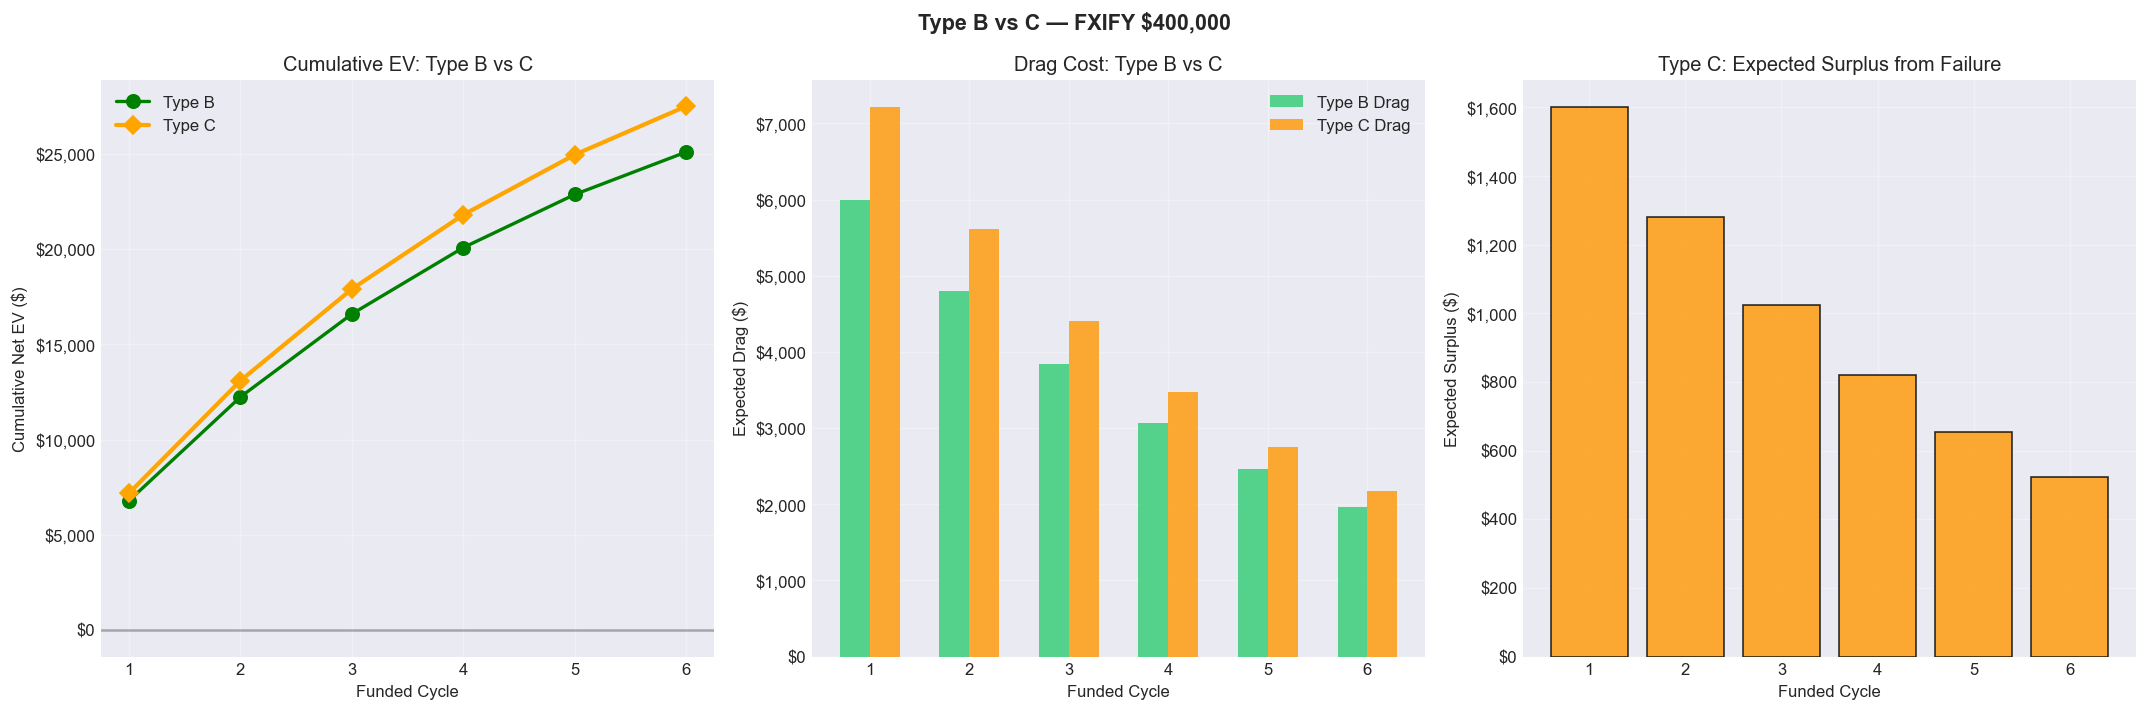

In [7]:
# Compare Type B and C funded phases side by side
cyc_b = best_b["cycles"]
cyc_c = best_c["cycles"]
nums = [c["cycle"] for c in cyc_c]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Panel 1: Cumulative net (withdrawals - drag)
cum_net_b = np.cumsum([c["exp_withdrawal"] - c["exp_drag"] for c in cyc_b])
cum_net_c = np.cumsum([c["exp_withdrawal"] - c["exp_drag"] + c["exp_surplus"] for c in cyc_c])

axes[0].plot(nums, cum_net_b, 'g-o', linewidth=2, markersize=8, label="Type B")
axes[0].plot(nums, cum_net_c, 'orange', marker='D', linewidth=2.5, markersize=8, label="Type C")
axes[0].axhline(y=0, color="black", linestyle="-", alpha=0.3)
axes[0].set_xlabel("Funded Cycle")
axes[0].set_ylabel("Cumulative Net EV ($)")
axes[0].set_title("Cumulative EV: Type B vs C")
axes[0].legend()
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].grid(alpha=0.3)

# Panel 2: Drag comparison
drag_b = [c["exp_drag"] for c in cyc_b]
drag_c = [c["exp_drag"] for c in cyc_c]
x = np.arange(len(nums))
axes[1].bar(x - 0.15, drag_b, 0.3, label="Type B Drag", color="#2ecc71", alpha=0.8)
axes[1].bar(x + 0.15, drag_c, 0.3, label="Type C Drag", color="#ff9800", alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(nums)
axes[1].set_xlabel("Funded Cycle")
axes[1].set_ylabel("Expected Drag ($)")
axes[1].set_title("Drag Cost: Type B vs C")
axes[1].legend()
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].grid(alpha=0.3)

# Panel 3: Expected surplus from failure
surplus_vals = [c["exp_surplus"] for c in cyc_c]
axes[2].bar(nums, surplus_vals, color="#ff9800", alpha=0.8, edgecolor="black")
axes[2].set_xlabel("Funded Cycle")
axes[2].set_ylabel("Expected Surplus ($)")
axes[2].set_title("Type C: Expected Surplus from Failure")
axes[2].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[2].grid(alpha=0.3)

plt.suptitle(f"Type B vs C — {best_c['firm']} ${best_c['account_size']:,}",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 6 — Surplus Target Sensitivity

How does the desired surplus percentage affect EV and capital?

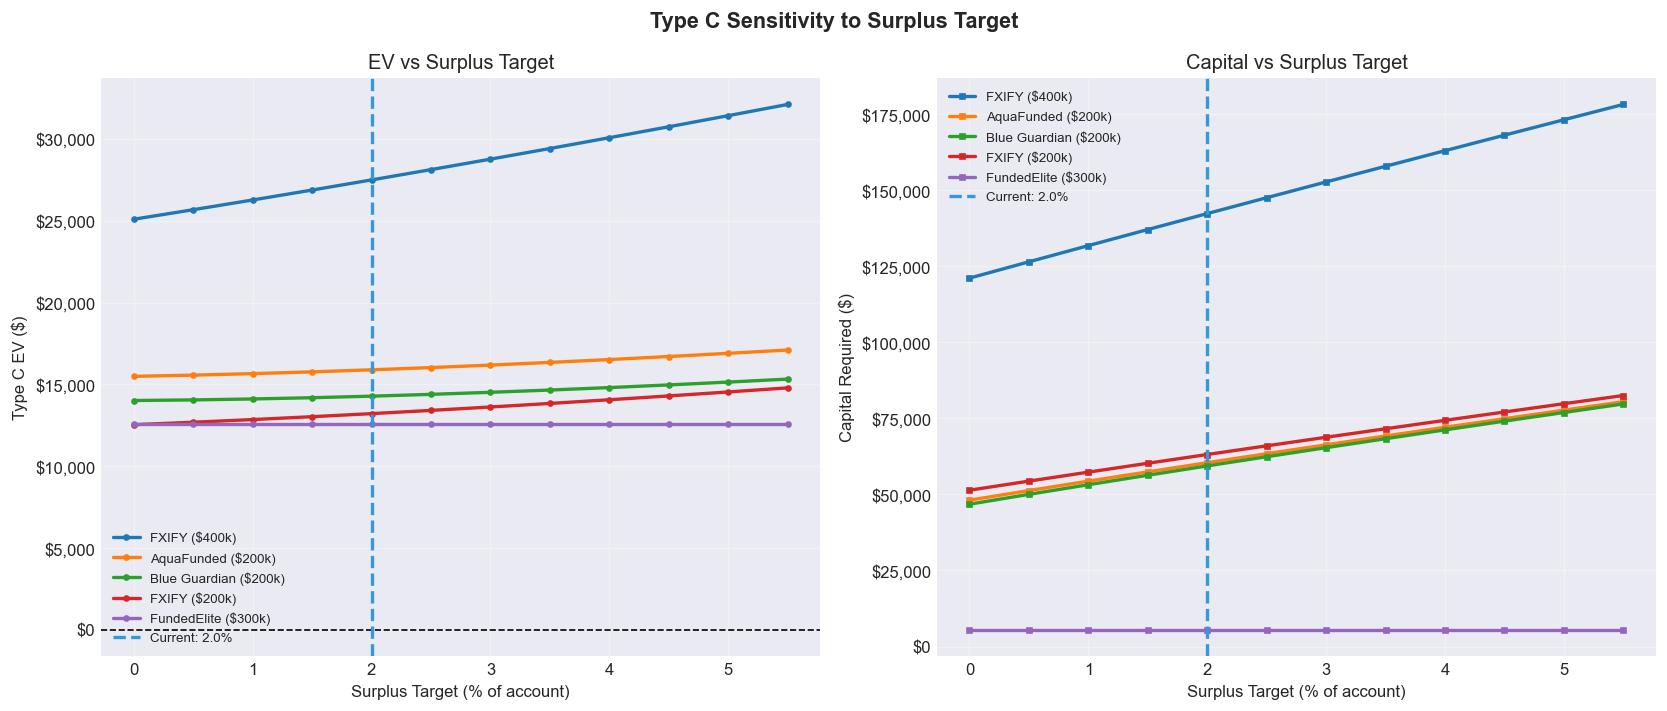

In [8]:
top5_idx = df_c.nlargest(5, "ev").index.tolist()
top5_ch = [challenges[i] for i in top5_idx]

surplus_sweep = np.arange(0, 0.06, 0.005)  # 0% to 5.5%

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
colors = plt.cm.tab10.colors

for i, ch in enumerate(top5_ch):
    evs = [compute_type_bc(ch, surplus_target_pct=sp)["ev"] for sp in surplus_sweep]
    caps = [compute_type_bc(ch, surplus_target_pct=sp)["capital_required"] for sp in surplus_sweep]
    label = f"{ch['firm']} (${ch['account_size']/1000:.0f}k)"

    ax1.plot(surplus_sweep * 100, evs, marker='o', markersize=3,
             label=label, linewidth=2, color=colors[i % 10])
    ax2.plot(surplus_sweep * 100, caps, marker='s', markersize=3,
             label=label, linewidth=2, color=colors[i % 10])

ax1.axhline(y=0, color="black", linestyle="--", linewidth=1)
ax1.axvline(x=SURPLUS_TARGET_PCT * 100, color="#3498db", linewidth=2, linestyle="--",
            label=f"Current: {SURPLUS_TARGET_PCT*100:.1f}%")
ax1.set_xlabel("Surplus Target (% of account)")
ax1.set_ylabel("Type C EV ($)")
ax1.set_title("EV vs Surplus Target")
ax1.legend(fontsize=8)
ax1.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax1.grid(alpha=0.3)

ax2.axvline(x=SURPLUS_TARGET_PCT * 100, color="#3498db", linewidth=2, linestyle="--",
            label=f"Current: {SURPLUS_TARGET_PCT*100:.1f}%")
ax2.set_xlabel("Surplus Target (% of account)")
ax2.set_ylabel("Capital Required ($)")
ax2.set_title("Capital vs Surplus Target")
ax2.legend(fontsize=8)
ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax2.grid(alpha=0.3)

plt.suptitle("Type C Sensitivity to Surplus Target", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 7 — All Three Types Summary Table

In [9]:
summary = pd.DataFrame({
    "firm": df_c["firm"],
    "size": df_c["account_size"],
    "dd": df_c["dd_category"],
    "fee": df_c["fee"],
    "EV_A": df_c["type_a_ev"],
    "EV_B": df_b["ev"],
    "EV_C": df_c["ev"],
    "B_vs_A": df_b["ev"] - df_c["type_a_ev"],
    "C_vs_B": df_c["ev"] - df_b["ev"],
    "Cap_A": [r["challenge_cost"] / r["dd_max_pct"] / 100 +
              r["challenge_cost"] / r["dd_max_pct"] * r["dd_max_pct"] * 1.5
              for r in [compute_type_a_cost(c) for c in challenges]],
    "Cap_C": df_c["capital_required"],
})

summary.sort_values("EV_C", ascending=False).head(20).style.format({
    "fee": "${:,.0f}",
    "size": "${:,}",
    "EV_A": "${:,.0f}",
    "EV_B": "${:,.0f}",
    "EV_C": "${:,.0f}",
    "B_vs_A": "${:+,.0f}",
    "C_vs_B": "${:+,.0f}",
    "Cap_A": "${:,.0f}",
    "Cap_C": "${:,.0f}",
}).bar(subset=["EV_C"], color="#ff9800").bar(
    subset=["EV_B"], color="#2ecc71"
).bar(subset=["EV_A"], color="#1976d2").set_caption(
    "Top 20 — All Three Hedge Types Compared"
)

,firm,size,dd,fee,EV_A,EV_B,EV_C,B_vs_A,C_vs_B,Cap_A,Cap_C
365,FXIFY,"$400,000",trailing,"$2,950","$-14,111","$25,087","$27,487","$+39,198","$+2,400","$25,846","$142,363"
332,AquaFunded,"$200,000",trailing,$897,"$2,325","$15,495","$15,893","$+13,170",$+398,"$7,859","$60,438"
333,Blue Guardian,"$200,000",trailing,$921,"$2,351","$14,019","$14,285","$+11,668",$+266,"$7,322","$59,387"
340,FXIFY,"$200,000",trailing,"$1,049","$-1,321","$12,544","$13,218","$+13,864",$+675,"$9,191","$63,139"
361,FundedElite,"$300,000",static,$899,"$12,574","$12,574","$12,574",$+0,$+0,"$5,384","$5,384"
364,Fintokei,"$400,000",static,"$2,399","$11,684","$11,684","$11,684",$+0,$+0,"$11,133","$11,133"
367,Nordic Funder,"$500,000",static,"$2,760","$11,657","$11,657","$11,657",$+0,$+0,"$16,529","$16,529"
320,Goat Funded Trader,"$150,000",trailing,$728,$675,"$9,408","$9,686","$+8,732",$+279,"$5,809","$45,160"
357,Audacity Capital,"$240,000",static,"$1,090","$9,529","$9,529","$9,529",$+0,$+0,"$3,815","$3,815"
362,FundedElite,"$300,000",static,"$1,499","$9,375","$9,375","$9,375",$+0,$+0,"$7,983","$7,983"


## 8 — Type C Summary

### What Type C tells you

**Static DD (cross-firm pair):**
- Type C is identical to Type B for static DD — surplus doesn't apply
- The cross-firm pair naturally extracts floor(DD/target) payouts, then both accounts expire
- There's no "failure event" to generate surplus from

**Trailing DD (personal hedge with surplus):**
- The failure event itself becomes a profit centre
- Hedge is oversized: $S = (L + P) / DD$ — more drag, but failure pays L + P
- EV_C = funded withdrawals + expected surplus - total drag
- The surplus target is tuneable — higher surplus = more drag = more capital

### When to use Type C over Type B

- You have enough capital to absorb the larger hedge
- You want to monetise the downside (funded failure becomes a deliberate payoff)
- You're willing to accept higher drag for a surplus payoff structure

### Important constraints

- **Cross-firm pairing ONLY** — never pair two funded accounts at the same prop firm
- Higher drag erodes funded-phase profits faster
- Capital requirement scales with surplus target
- Trailing DD challenges become expensive under Type C (drag compounds)

---

**See also:**
- [Type A](type_a_challenge_insurance.ipynb) — Challenge-only (cross-firm or personal)
- [Type B](type_b_funded_recovery.ipynb) — Funded-continuation recovery
- [hedging-explained.md](../Product/hedging-explained.md) — Full knowledge base